## project 

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data set leo gave us
mydata = "/Users/edgarherrera/Desktop/Cursor/projects/project_leo_dataset/csv"


## stat padding for teams below:

In [36]:
# loading games - only regular season
games = pd.read_csv(f"{mydata}/game.csv")
games = games[games["season_type"] == "Regular Season"].copy()  # only regular season
games["season"] = games["season_id"].astype(str).str[-2:].astype(int)
# keeping 1997+ bc older seasons had missing 3pt data
games = games[games["season_id"] >= 21997].copy()

print(f"games loaded: {len(games):,} | seasons: {games['season_id'].min()} to {games['season_id'].max()}")
games.head(10)

games loaded: 29,438 | seasons: 21997 to 22022


,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type,season
32798,21997,1610612765,DET,Detroit Pistons,29700007,1997-10-31 00:00:00,DET vs. WAS,W,240,32.0,...,22.0,7.0,2.0,15.0,31.0,79.0,-13,0,Regular Season,97
32799,21997,1610612748,MIA,Miami Heat,29700005,1997-10-31 00:00:00,MIA vs. TOR,W,240,41.0,...,17.0,10.0,7.0,12.0,18.0,101.0,-13,0,Regular Season,97
32800,21997,1610612743,DEN,Denver Nuggets,29700010,1997-10-31 00:00:00,DEN vs. SAS,L,240,36.0,...,18.0,7.0,9.0,18.0,21.0,107.0,11,0,Regular Season,97
32801,21997,1610612747,LAL,Los Angeles Lakers,29700012,1997-10-31 00:00:00,LAL vs. UTA,W,240,33.0,...,16.0,7.0,8.0,16.0,35.0,87.0,-17,0,Regular Season,97
32802,21997,1610612763,VAN,Vancouver Grizzlies,29700014,1997-10-31 00:00:00,VAN vs. DAL,L,240,36.0,...,18.0,5.0,8.0,18.0,21.0,90.0,2,0,Regular Season,97
32803,21997,1610612751,NJN,New Jersey Nets,29700002,1997-10-31 00:00:00,NJN vs. IND,W,240,34.0,...,22.0,2.0,5.0,21.0,32.0,95.0,-2,0,Regular Season,97
32804,21997,1610612745,HOU,Houston Rockets,29700009,1997-10-31 00:00:00,HOU vs. CLE,W,240,33.0,...,11.0,14.0,3.0,18.0,27.0,86.0,-8,0,Regular Season,97
32805,21997,1610612756,PHX,Phoenix Suns,29700011,1997-10-31 00:00:00,PHX vs. LAC,W,240,38.0,...,25.0,9.0,7.0,21.0,27.0,100.0,-10,0,Regular Season,97
32806,21997,1610612750,MIN,Minnesota Timberwolves,29700008,1997-10-31 00:00:00,MIN vs. GSW,W,240,49.0,...,24.0,7.0,11.0,12.0,22.0,113.0,-16,0,Regular Season,97
32807,21997,1610612766,CHH,Charlotte Hornets,29700006,1997-10-31 00:00:00,CHH vs. NYK,L,240,26.0,...,27.0,5.0,6.0,17.0,38.0,97.0,12,0,Regular Season,97


In [37]:
# need each game as 2 rows so i can aggregate by team (home + away)
home = games[["season_id", "season", "game_id", "team_id_home", "team_abbreviation_home", "team_name_home", 
              "wl_home", "pts_home", "reb_home", "ast_home", "stl_home", "blk_home", "tov_home",
              "fg_pct_home", "fg3_pct_home", "ft_pct_home"]].copy()
home.columns = ["season_id", "season", "game_id", "team_id", "team_abbr", "team_name", "win",
                "pts", "reb", "ast", "stl", "blk", "tov", "fg_pct", "fg3_pct", "ft_pct"]

away = games[["season_id", "season", "game_id", "team_id_away", "team_abbreviation_away", "team_name_away",
              "wl_away", "pts_away", "reb_away", "ast_away", "stl_away", "blk_away", "tov_away",
              "fg_pct_away", "fg3_pct_away", "ft_pct_away"]].copy()
away.columns = ["season_id", "season", "game_id", "team_id", "team_abbr", "team_name", "win",
                "pts", "reb", "ast", "stl", "blk", "tov", "fg_pct", "fg3_pct", "ft_pct"]

team_games = pd.concat([home, away], ignore_index=True)
team_games["win"] = (team_games["win"] == "W").astype(int)  # W=1 L=0
print(f"team-game rows: {len(team_games):,}")
team_games.head()


team-game rows: 58,876


,season_id,season,game_id,team_id,team_abbr,team_name,win,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct
0,21997,97,29700007,1610612765,DET,Detroit Pistons,1,92.0,51.0,11.0,8.0,4.0,14.0,0.438,0.250,0.643
1,21997,97,29700005,1610612748,MIA,Miami Heat,1,114.0,50.0,28.0,3.0,7.0,15.0,0.471,0.480,0.870
2,21997,97,29700010,1610612743,DEN,Denver Nuggets,0,96.0,34.0,12.0,9.0,3.0,14.0,0.424,0.444,0.769
3,21997,97,29700012,1610612747,LAL,Los Angeles Lakers,1,104.0,43.0,27.0,9.0,9.0,11.0,0.423,0.414,0.703
4,21997,97,29700014,1610612763,VAN,Vancouver Grizzlies,0,88.0,44.0,25.0,7.0,4.0,16.0,0.404,0.154,0.700


In [38]:
# grouping by team + season to get wins and avg stats per game
team_season = team_games.groupby(["team_id", "team_abbr", "team_name", "season_id"]).agg(
    wins=("win", "sum"),
    games=("game_id", "count"),
    pts=("pts", "mean"),
    reb=("reb", "mean"),
    ast=("ast", "mean"),
    stl=("stl", "mean"),
    blk=("blk", "mean"),
    tov=("tov", "mean"),
    fg_pct=("fg_pct", "mean"),
    fg3_pct=("fg3_pct", "mean"),
    ft_pct=("ft_pct", "mean"),
).reset_index()

team_season = team_season.dropna()  # dropping nas
print(f"team-seasons: {len(team_season):,}")
team_season.head(10)

team-seasons: 743


,team_id,team_abbr,team_name,season_id,wins,games,pts,reb,ast,stl,blk,tov,fg_pct,fg3_pct,ft_pct
0,1610612737,ATL,Atlanta Hawks,21997,50,82,95.853659,42.963415,19.134146,7.963415,5.987805,14.804878,0.455415,0.314902,0.756512
1,1610612737,ATL,Atlanta Hawks,21998,31,50,86.300000,43.500000,15.640000,6.920000,5.200000,14.880000,0.408440,0.295220,0.734020
2,1610612737,ATL,Atlanta Hawks,21999,28,82,94.329268,45.317073,18.878049,6.097561,5.621951,15.439024,0.442439,0.325085,0.745268
3,1610612737,ATL,Atlanta Hawks,22000,25,82,90.963415,42.902439,19.012195,7.731707,4.719512,16.682927,0.431305,0.359317,0.765671
4,1610612737,ATL,Atlanta Hawks,22001,33,82,94.036585,41.463415,20.195122,8.134146,4.268293,15.536585,0.439732,0.352390,0.762427
5,1610612737,ATL,Atlanta Hawks,22002,35,82,94.073171,42.621951,20.475610,7.451220,5.768293,16.670732,0.444963,0.354976,0.788634
6,1610612737,ATL,Atlanta Hawks,22003,28,82,92.817073,42.719512,20.097561,7.646341,4.975610,16.353659,0.433756,0.320012,0.771976
7,1610612737,ATL,Atlanta Hawks,22004,13,82,92.743902,41.890244,19.682927,7.670732,4.195122,16.085366,0.441207,0.308085,0.706561
8,1610612737,ATL,Atlanta Hawks,22005,26,82,97.219512,40.256098,19.817073,7.158537,4.804878,15.658537,0.454963,0.354988,0.746646
9,1610612737,ATL,Atlanta Hawks,22006,30,82,93.658537,40.097561,19.182927,7.426829,5.439024,15.926829,0.444780,0.323354,0.764854


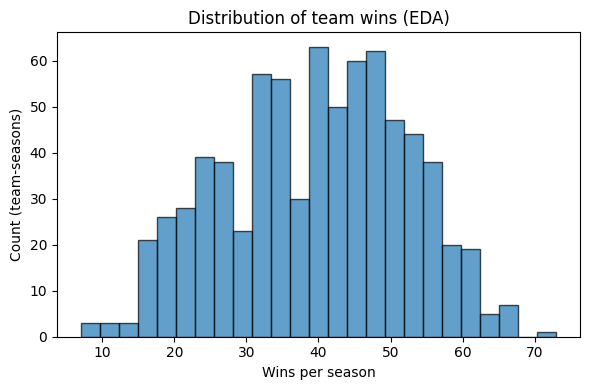

In [39]:
# EDA: distribution of team wins (before regression)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(team_season["wins"], bins=25, edgecolor="black", alpha=0.7)
ax.set_xlabel("Wins per season")
ax.set_ylabel("Count (team-seasons)")
ax.set_title("Distribution of team wins (EDA)")
plt.tight_layout()
plt.show()

In [40]:
# running regression to predict wins from box score stats
feature_cols = ["pts", "reb", "ast", "stl", "blk", "tov", "fg_pct", "fg3_pct", "ft_pct"]
X = team_season[feature_cols].values
y = team_season["wins"].values
X_with_intercept = np.column_stack([np.ones(len(X)), X])  # adding intercept

# fitting - lstsq is least squares
coefs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
team_season["wins_predicted"] = X_with_intercept @ coefs
team_season["residual"] = team_season["wins"] - team_season["wins_predicted"]

# neg residual = stat padding so flipping it
team_season["stat_padding_score"] = -team_season["residual"]

# r squared
ss_res = np.sum(team_season["residual"] ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print("regression: wins ~ pts + reb + ast + stl + blk + tov + fg_pct + fg3_pct + ft_pct")
print(f"r² = {r_squared:.3f}")
print("coefficients (per 1 unit increase):")
for col, coef in zip(feature_cols, coefs[1:]):
    print(f"  {col}: {coef:.2f}")

regression: wins ~ pts + reb + ast + stl + blk + tov + fg_pct + fg3_pct + ft_pct
r² = 0.633
coefficients (per 1 unit increase):
  pts: -1.14
  reb: 3.10
  ast: -0.27
  stl: 4.09
  blk: 0.71
  tov: -3.60
  fg_pct: 550.85
  fg3_pct: 160.66
  ft_pct: 41.24


/var/folders/bx/bbnzdfvx2x54xk6pzqh0y0b80000gn/T/ipykernel_2719/3139689410.py:9: RuntimeWarning: divide by zero encountered in matmul
  team_season["wins_predicted"] = X_with_intercept @ coefs
/var/folders/bx/bbnzdfvx2x54xk6pzqh0y0b80000gn/T/ipykernel_2719/3139689410.py:9: RuntimeWarning: overflow encountered in matmul
  team_season["wins_predicted"] = X_with_intercept @ coefs
/var/folders/bx/bbnzdfvx2x54xk6pzqh0y0b80000gn/T/ipykernel_2719/3139689410.py:9: RuntimeWarning: invalid value encountered in matmul
  team_season["wins_predicted"] = X_with_intercept @ coefs


In [41]:
# who are the top 10 stat padders
stat_padders = team_season.nlargest(10, "stat_padding_score")[
    ["season_id", "team_abbr", "team_name", "wins", "wins_predicted", "residual", "pts", "reb", "ast"]
]
stat_padders.columns = ["season", "team", "name", "actual_wins", "predicted_wins", "residual", "pts/g", "reb/g", "ast/g"]
print("top 10 stat-padding teams (stats don't translate to wins)")
stat_padders

top 10 stat-padding teams (stats don't translate to wins)


,season,team,name,actual_wins,predicted_wins,residual,pts/g,reb/g,ast/g
459,22011,PHI,Philadelphia 76ers,35,59.357114,-24.357114,93.636364,43.151515,22.015152
471,21998,PHX,Phoenix Suns,27,48.288597,-21.288597,95.580000,40.320000,24.980000
296,21998,MIL,Milwaukee Bucks,28,48.968963,-20.968963,91.680000,38.780000,20.600000
184,22011,GSW,Golden State Warriors,23,43.752624,-20.752624,97.772727,39.196970,22.272727
566,22019,SAS,San Antonio Spurs,32,51.647815,-19.647815,114.056338,44.647887,24.661972
82,22011,NOH,New Orleans Hornets,21,40.058864,-19.058864,89.636364,41.136364,20.727273
121,21998,DAL,Dallas Mavericks,19,37.448407,-18.448407,91.620000,42.460000,18.420000
720,22004,CHA,Charlotte Bobcats,18,36.306338,-18.306338,94.256098,41.682927,21.878049
347,22015,BKN,Brooklyn Nets,21,38.665863,-17.665863,98.646341,42.402439,22.304878
92,22020,NOP,New Orleans Pelicans,31,47.879032,-16.879032,114.597222,47.402778,26.000000


In [42]:
# top 10 high impact teams
high_impact = team_season.nsmallest(10, "stat_padding_score")[
    ["season_id", "team_abbr", "team_name", "wins", "wins_predicted", "residual", "pts", "reb", "ast"]
]
high_impact.columns = ["season", "team", "name", "actual_wins", "predicted_wins", "residual", "pts/g", "reb/g", "ast/g"]
print("top 10 high-impact teams (wins exceed what stats predict)")
high_impact

top 10 high-impact teams (wins exceed what stats predict)


,season,team,name,actual_wins,predicted_wins,residual,pts/g,reb/g,ast/g
211,22014,HOU,Houston Rockets,56,31.507081,24.492919,103.926829,43.682927,22.195122
214,22017,HOU,Houston Rockets,65,41.137970,23.862030,112.353659,43.463415,21.548780
215,22018,HOU,Houston Rockets,53,30.669750,22.330250,113.914634,42.060976,21.231707
213,22016,HOU,Houston Rockets,55,32.887700,22.112300,115.341463,44.365854,25.243902
30,22002,BOS,Boston Celtics,44,22.662612,21.337388,92.670732,40.487805,19.207317
363,22005,NJN,New Jersey Nets,49,28.635524,20.364476,93.792683,40.987805,22.975610
426,22003,IND,Indiana Pacers,61,42.186357,18.813643,91.378049,41.670732,21.634146
102,22004,CHI,Chicago Bulls,47,29.210617,17.789383,94.451220,43.804878,21.256098
43,22016,BOS,Boston Celtics,53,35.457209,17.542791,108.012195,41.963415,25.231707
273,22000,MIA,Miami Heat,50,32.476272,17.523728,88.890244,39.609756,19.878049


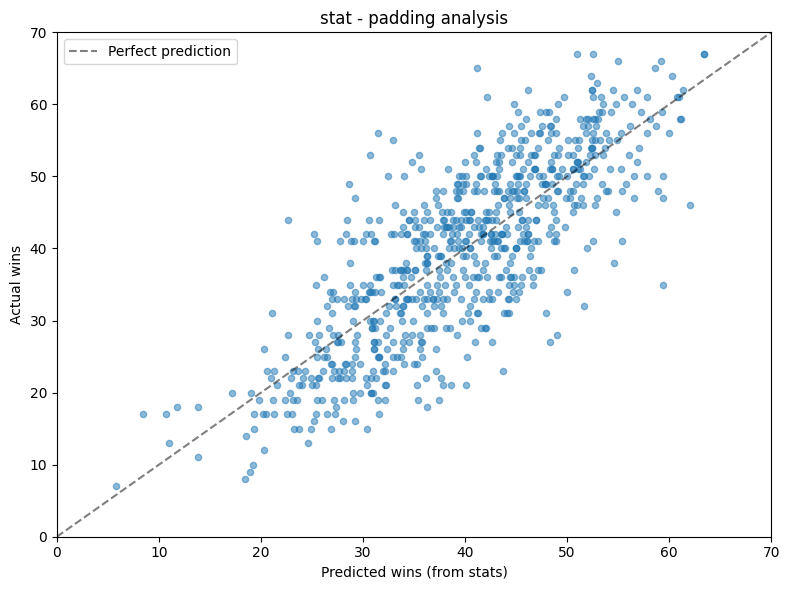

In [43]:
# plotting - below line = stat padding above = high impact
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(team_season["wins_predicted"], team_season["wins"], alpha=0.5, s=20)
ax.plot([0, 70], [0, 70], "k--", alpha=0.5, label="Perfect prediction")
ax.set_xlabel("Predicted wins (from stats)")
ax.set_ylabel("Actual wins")
ax.set_title("stat - padding analysis")
ax.legend()
ax.set_xlim(0, 70)
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()

In [44]:
# quick recap
print("team stat-padding: residual = actual wins - predicted wins")
print("negative residual = stat padding | positive = high impact")

team stat-padding: residual = actual wins - predicted wins
negative residual = stat padding | positive = high impact


---
## stat padding for PLAYERS (mvp data)

In [45]:
# same thing for players - using mvp data
MVP_PATH = mydata.replace("/csv", "") + "/mvp_votings.csv"
mvp = pd.read_csv(MVP_PATH)

# ws = win shares (outcome), predicting from these stats
feature_cols = ["pts_per_g", "trb_per_g", "ast_per_g", "stl_per_g", "blk_per_g", "fg_pct", "fg3_pct", "ft_pct"]
outcome_col = "ws"

mvp_clean = mvp[[outcome_col, "player", "season"] + feature_cols].dropna()
print(f"player-seasons: {len(mvp_clean):,} (mvp vote recipients)")
mvp_clean.head(10)

player-seasons: 637 (mvp vote recipients)


,ws,player,season,pts_per_g,trb_per_g,ast_per_g,stl_per_g,blk_per_g,fg_pct,fg3_pct,ft_pct
0,13.8,Julius Erving,1980-81,24.6,8.0,4.4,2.1,1.8,0.521,0.222,0.787
1,10.8,Larry Bird,1980-81,21.2,10.9,5.5,2.0,0.8,0.478,0.270,0.863
2,14.3,Kareem Abdul-Jabbar,1980-81,26.2,10.3,3.4,0.7,2.9,0.574,0.000,0.766
3,13.7,Moses Malone,1980-81,27.8,14.8,1.8,1.0,1.9,0.522,0.333,0.757
4,10.5,George Gervin,1980-81,27.1,5.1,3.2,1.1,0.7,0.492,0.257,0.826
5,11.2,Marques Johnson,1980-81,20.3,6.8,4.6,1.5,0.5,0.552,0.000,0.706
6,10.9,Robert Parish,1980-81,18.9,9.5,1.8,1.0,2.6,0.545,0.000,0.710
7,8.4,Dennis Johnson,1980-81,18.8,4.6,3.7,1.7,0.8,0.436,0.216,0.820
8,6.9,Tiny Archibald,1980-81,13.8,2.2,7.7,0.9,0.2,0.499,0.000,0.816
9,8.5,Jamaal Wilkes,1980-81,22.6,5.4,2.9,1.5,0.4,0.526,0.077,0.758


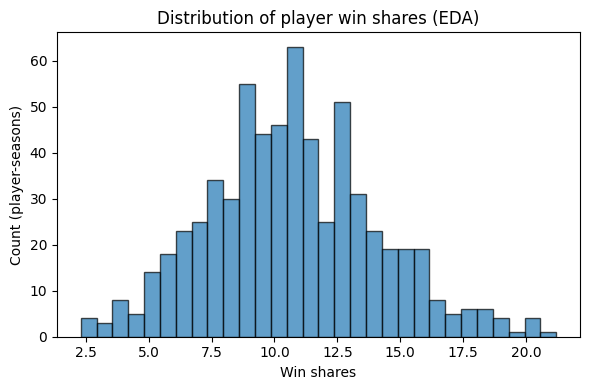

In [46]:
# EDA: distribution of player win shares (before regression)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mvp_clean["ws"], bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("Win shares")
ax.set_ylabel("Count (player-seasons)")
ax.set_title("Distribution of player win shares (EDA)")
plt.tight_layout()
plt.show()

In [47]:
# had to standardize - was getting overflow
X = mvp_clean[feature_cols].values
y = mvp_clean[outcome_col].values
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_std[X_std == 0] = 1  # avoid div by zero
X_scaled = (X - X_mean) / X_std
X_with_intercept = np.column_stack([np.ones(len(X_scaled)), X_scaled])

# same regression - predicting ws from stats
coefs, _, _, _ = np.linalg.lstsq(X_with_intercept, y, rcond=None)
mvp_clean = mvp_clean.copy()
mvp_clean["ws_predicted"] = X_with_intercept @ coefs
mvp_clean["residual"] = mvp_clean[outcome_col] - mvp_clean["ws_predicted"]
mvp_clean["stat_padding_score"] = -mvp_clean["residual"]

# r squared
ss_res = np.sum(mvp_clean["residual"] ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print("regression: win_shares ~ pts_per_g + trb_per_g + ast_per_g + stl_per_g + blk_per_g + fg_pct + fg3_pct + ft_pct")
print(f"r² = {r_squared:.3f}")

regression: win_shares ~ pts_per_g + trb_per_g + ast_per_g + stl_per_g + blk_per_g + fg_pct + fg3_pct + ft_pct
r² = 0.553


/var/folders/bx/bbnzdfvx2x54xk6pzqh0y0b80000gn/T/ipykernel_2719/2576605913.py:12: RuntimeWarning: divide by zero encountered in matmul
  mvp_clean["ws_predicted"] = X_with_intercept @ coefs
/var/folders/bx/bbnzdfvx2x54xk6pzqh0y0b80000gn/T/ipykernel_2719/2576605913.py:12: RuntimeWarning: overflow encountered in matmul
  mvp_clean["ws_predicted"] = X_with_intercept @ coefs
/var/folders/bx/bbnzdfvx2x54xk6pzqh0y0b80000gn/T/ipykernel_2719/2576605913.py:12: RuntimeWarning: invalid value encountered in matmul
  mvp_clean["ws_predicted"] = X_with_intercept @ coefs


In [48]:
# top 15 player stat padders
stat_padders = mvp_clean.nlargest(15, "stat_padding_score")[
    ["season", "player", outcome_col, "ws_predicted", "residual", "pts_per_g", "trb_per_g", "ast_per_g"]
]
stat_padders.columns = ["Season", "Player", "Actual WS", "Predicted WS", "Residual", "Pts/G", "Reb/G", "Ast/G"]
print("top 15 stat-padding players (stats don't translate to win shares)")
stat_padders

top 15 stat-padding players (stats don't translate to win shares)


,Season,Player,Actual WS,Predicted WS,Residual,Pts/G,Reb/G,Ast/G
280,1994-95,Michael Jordan,2.3,10.778282,-8.478282,26.9,6.9,5.3
10,1980-81,Magic Johnson,6.4,14.693851,-8.293851,21.6,8.6,8.6
235,1991-92,Larry Bird,5.5,12.409578,-6.909578,20.2,9.6,6.8
217,1990-91,Bernard King,3.5,9.787809,-6.287809,28.4,5.0,4.6
210,1990-91,Larry Bird,6.6,12.223726,-5.623726,19.4,8.5,7.2
219,1990-91,Hakeem Olajuwon,8.6,13.972407,-5.372407,21.2,13.8,2.3
100,1984-85,Bernard King,7.1,12.346890,-5.246890,32.9,5.8,3.7
81,1983-84,Magic Johnson,10.2,15.243339,-5.043339,17.6,7.3,13.1
350,1998-99,Kevin Garnett,5.4,10.238739,-4.838739,20.8,10.4,4.3
635,2017-18,Joel Embiid,6.2,10.980545,-4.780545,22.9,11.0,3.2


In [49]:
# top 15 high impact players
high_impact = mvp_clean.nsmallest(15, "stat_padding_score")[
    ["season", "player", outcome_col, "ws_predicted", "residual", "pts_per_g", "trb_per_g", "ast_per_g"]
]
high_impact.columns = ["Season", "Player", "Actual WS", "Predicted WS", "Residual", "Pts/G", "Reb/G", "Ast/G"]
print("top 15 high-impact players (win shares exceed what box-score stats predict)")
high_impact

top 15 high-impact players (win shares exceed what box-score stats predict)


,Season,Player,Actual WS,Predicted WS,Residual,Pts/G,Reb/G,Ast/G
462,2005-06,Chauncey Billups,15.5,8.263375,7.236625,18.5,3.1,8.6
503,2008-09,LeBron James,20.3,13.651676,6.648324,28.4,7.6,7.2
285,1995-96,Michael Jordan,20.4,13.892009,6.507991,30.4,6.6,4.3
432,2003-04,Ben Wallace,10.2,3.887341,6.312659,9.5,12.4,1.7
404,2001-02,Ben Wallace,11.6,5.562321,6.037679,7.6,13.0,1.4
303,1996-97,Michael Jordan,18.3,12.542481,5.757519,29.6,5.9,4.3
362,1999-00,Shaquille O'Neal,18.6,13.227986,5.372014,29.7,13.6,3.8
322,1997-98,Michael Jordan,15.8,10.460226,5.339774,28.7,5.8,3.5
420,2002-03,Ben Wallace,10.6,5.268130,5.331870,6.9,15.4,1.6
460,2005-06,Dirk Nowitzki,17.7,12.429291,5.270709,26.6,9.0,2.8


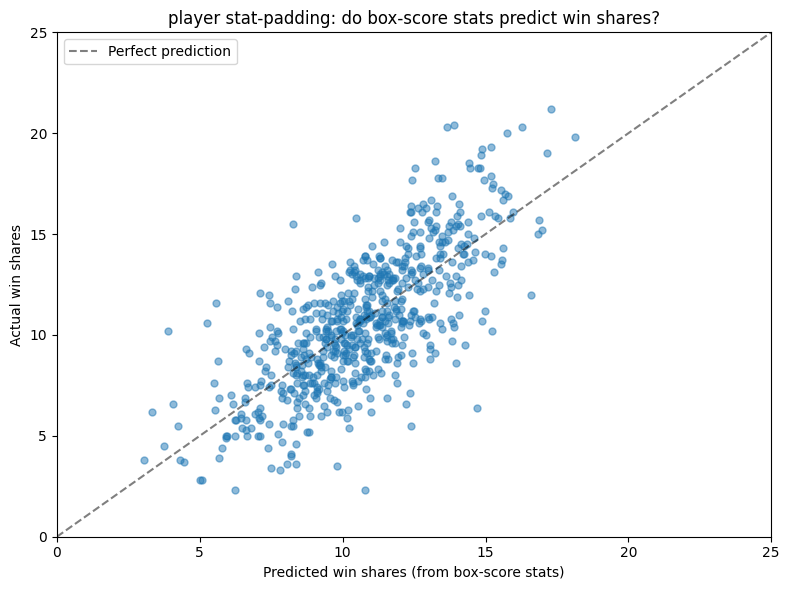

In [50]:
# scatter for players - same idea
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mvp_clean["ws_predicted"], mvp_clean[outcome_col], alpha=0.5, s=25)
ax.plot([0, 25], [0, 25], "k--", alpha=0.5, label="Perfect prediction")
ax.set_xlabel("Predicted win shares (from box-score stats)")
ax.set_ylabel("Actual win shares")
ax.set_title("player stat-padding: do box-score stats predict win shares?")
ax.legend()
ax.set_xlim(0, 25)
ax.set_ylim(0, 25)
plt.tight_layout()
plt.show()

In [51]:
# same thing as teams
print("some notes to keep in mind are below:")
print("player stat-padding: residual = actual ws - predicted ws")
print("negative residual = stat padding | positive = high impact")

some notes to keep in mind are below:
player stat-padding: residual = actual ws - predicted ws
negative residual = stat padding | positive = high impact


In [ ]:
team_season.to_csv("team_season_stat_padding.csv", index=False)
mvp_clean.to_csv("mvp_clean_stat_padding.csv", index=False)
try:
    stat_padders.to_csv("team_stat_padders.csv", index=False)
    high_impact.to_csv("team_high_impact.csv", index=False)
except NameError:
    pass

try:
    stat_padders.to_csv("player_stat_padders.csv", index=False)
    high_impact.to_csv("player_high_impact.csv", index=False)
except NameError:
    pass
#saved files

csv files written to current folder (if corresponding tables existed).
